In [1]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import json

model_path = "../models/saved_model"

tokenizer = BertTokenizer.from_pretrained(model_path)
model = BertForSequenceClassification.from_pretrained(model_path)



2025-10-05 23:59:39.502141: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-05 23:59:39.542662: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-05 23:59:40.379631: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load combined dataset
df = pd.read_csv("../data/combined.csv")

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

# Tokenize
test_encodings = tokenizer(list(map(str, test_texts)),
                           truncation=True, padding=True, max_length=256)

# Define dataset class
class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(int(self.labels.iloc[idx]))
        return item

test_dataset = EmailDataset(test_encodings, test_labels)


In [3]:
trainer = Trainer(model=model)


Test Results: {'eval_loss': 0.015732120722532272, 'eval_model_preparation_time': 0.0013, 'eval_runtime': 192.8227, 'eval_samples_per_second': 190.46, 'eval_steps_per_second': 23.809}


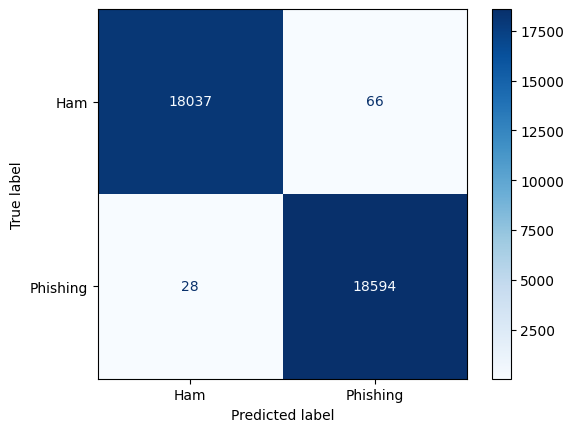

In [4]:
# Evaluate on test set
results = trainer.evaluate(test_dataset)
print("Test Results:", results)

# Save to JSON
with open("test_results.json", "w") as f:
    json.dump(results, f, indent=4)

# Predictions
preds = trainer.predict(test_dataset).predictions.argmax(-1)
labels = test_dataset.labels

# Confusion matrix
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham", "Phishing"])
disp.plot(cmap="Blues")
plt.show()
